**Imports**

In [ ]:

#  CELL 1:Install dependencies




!pip install timm -q

import os
import sys
import random
import shutil
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")
print(f"✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

✅ Device: cuda
✅ GPU: Tesla T4


**Loading Zoomnext model**

In [ ]:

#  CELL 2: Load ZoomNeXt PVTv2-B4


# ──────────────────────────────────────────────
#   SET YOUR PATHS
# ──────────────────────────────────────────────
ZOOMNEXT_DIR = "/content/drive/MyDrive/ZoomNeXt_folder/ZoomNeXt"       # ← e.g. "/content/ZoomNeXt"
B4_WEIGHT_PATH = "/content/drive/MyDrive/ZoomNeXt_folder/ZoomNeXt/pretrained_weights/pvtv2-b4-zoomnext.pth"     # ← e.g. "/content/ZoomNeXt/pretrained_weights/zoomnext_b4.pth"
# ──────────────────────────────────────────────

sys.path.insert(0, ZOOMNEXT_DIR)
from methods import PvtV2B4_ZoomNeXt

zoomnext_b4 = PvtV2B4_ZoomNeXt(pretrained=False)
zoomnext_b4.to(device)

ckpt = torch.load(B4_WEIGHT_PATH, map_location=device)
if "state_dict" in ckpt:
    zoomnext_b4.load_state_dict(ckpt["state_dict"])
elif "net" in ckpt:
    zoomnext_b4.load_state_dict(ckpt["net"])
else:
    zoomnext_b4.load_state_dict(ckpt)

zoomnext_b4.eval()
print(f"✅ ZoomNeXt B4 loaded ({sum(p.numel() for p in zoomnext_b4.parameters()):,} params)")

BASE_H, BASE_W = 384, 384
THRESHOLD = 0.5

def predict_mask(image_path, model, threshold=THRESHOLD):
    img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = img.size
    img_np = np.array(img)

    img_s = cv2.resize(img_np, (int(BASE_W * 0.5), int(BASE_H * 0.5)))
    img_m = cv2.resize(img_np, (BASE_W, BASE_H))
    img_l = cv2.resize(img_np, (int(BASE_W * 1.5), int(BASE_H * 1.5)))

    image_s = torch.from_numpy(img_s).float().div(255).permute(2, 0, 1).unsqueeze(0).to(device)
    image_m = torch.from_numpy(img_m).float().div(255).permute(2, 0, 1).unsqueeze(0).to(device)
    image_l = torch.from_numpy(img_l).float().div(255).permute(2, 0, 1).unsqueeze(0).to(device)

    data = {"image_s": image_s, "image_m": image_m, "image_l": image_l}

    with torch.no_grad():
        logits = model(data)
        prob_map = torch.sigmoid(logits)
        prob_map = F.interpolate(prob_map, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
        prob_map = prob_map.squeeze().cpu().numpy()

    mask = (prob_map > threshold).astype(np.uint8)
    has_object = (mask.sum() / mask.size) > 0.005
    return mask, prob_map, has_object


def get_bounding_box(mask, padding=0.15):
    coords = np.where(mask > 0)
    if len(coords[0]) == 0:
        return None
    y1, y2 = coords[0].min(), coords[0].max()
    x1, x2 = coords[1].min(), coords[1].max()
    h, w = mask.shape
    py = int((y2 - y1) * padding)
    px = int((x2 - x1) * padding)
    return (max(0, x1 - px), max(0, y1 - py), min(w, x2 + px), min(h, y2 + py))

print("✅ Detection functions ready")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


✅ ZoomNeXt B4 loaded (65,373,885 params)
✅ Detection functions ready


**Marking soldier using Zoomnext in cam and no cam**

In [ ]:

#  CELL 3: Crop ALL images using ZoomNeXt B4


# ──────────────────────────────────────────────
#   SET YOUR PATHS
# ──────────────────────────────────────────────
INPUT_ROOT = "/content/drive/MyDrive/split_dataset"          # ← SPLIT DATASET PATH FROM CELL 2
CROPPED_ROOT = "/content/drive/MyDrive/croppedcamdata"        # ← WHERE TO SAVE CROPPED IMAGES
# ──────────────────────────────────────────────

CROP_SIZE = 224

if os.path.exists(CROPPED_ROOT):
    shutil.rmtree(CROPPED_ROOT)

stats = {"cropped": 0, "full": 0, "errors": 0}

for split in ["train", "val", "test"]:
    for cls in ["cam", "no_cam"]:
        src_dir = os.path.join(INPUT_ROOT, split, cls)
        dst_dir = os.path.join(CROPPED_ROOT, split, cls)
        os.makedirs(dst_dir, exist_ok=True)

        images = [f for f in Path(src_dir).iterdir()
                  if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]

        for img_path in tqdm(images, desc=f"{split}/{cls}"):
            try:
                mask, prob_map, has_object = predict_mask(str(img_path), zoomnext_b4)
                img = Image.open(str(img_path)).convert("RGB")

                if has_object:
                    bbox = get_bounding_box(mask)
                    if bbox:
                        x1, y1, x2, y2 = bbox
                        cropped = img.crop((x1, y1, x2, y2))
                        cropped = cropped.resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS)
                        stats["cropped"] += 1
                    else:
                        cropped = img.resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS)
                        stats["full"] += 1
                else:
                    cropped = img.resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS)
                    stats["full"] += 1

                save_path = os.path.join(dst_dir, img_path.name)
                cropped.save(save_path, quality=95)

            except Exception as e:
                print(f"  ❌ {img_path.name}: {e}")
                stats["errors"] += 1

print(f"\n{'='*50}")
print(f"  CROPPING COMPLETE")
print(f"{'='*50}")
print(f"  Cropped (soldier found): {stats['cropped']}")
print(f"  Full image (no detect):  {stats['full']}")
print(f"  Errors:                  {stats['errors']}")
print(f"  Total:                   {stats['cropped'] + stats['full']}")
print(f"{'='*50}")

for split in ["train", "val", "test"]:
    for cls in ["cam", "no_cam"]:
        path = os.path.join(CROPPED_ROOT, split, cls)
        count = len(list(Path(path).iterdir()))
        print(f"  {split}/{cls}: {count}")

train/cam:   0%|          | 0/1931 [00:00<?, ?it/s]/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
test/no_cam: 100%|██████████| 259/259 [01:20<00:00,  3.23it/s]


  CROPPING COMPLETE
  Cropped (soldier found): 4634
  Full image (no detect):  525
  Errors:                  0
  Total:                   5159
  train/cam: 1931
  train/no_cam: 1938
  val/cam: 386
  val/no_cam: 387
  test/cam: 258
  test/no_cam: 259


**SWIN MODEL**

In [ ]:

#  CELL 4: Swin V2-Small — RUN BEFORE CELL 5


NUM_CLASSES = 2
INPUT_SIZE = 256

model = timm.create_model("swinv2_small_window8_256", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Swin V2-Small loaded")
print(f"  Params:     {total_params:,}")
print(f"  Input size: {INPUT_SIZE}×{INPUT_SIZE}")
print(f"  Classes:    {NUM_CLASSES}")

if torch.cuda.is_available():
    vram = torch.cuda.memory_allocated() / 1024**3
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"  VRAM:       {vram:.1f}GB / {total_vram:.1f}GB")

print(f"\n  Model comparison:")
print(f"    Swin V2-Tiny:   28M params (previous)")
print(f"    Swin V2-Small:  {total_params/1e6:.1f}M params (current) ← sweet spot")
print(f"    Swin-Base V1:   88M params (too heavy)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

✅ Swin V2-Small loaded
  Params:     48,960,956
  Input size: 256×256
  Classes:    2
  VRAM:       0.7GB / 14.6GB

  Model comparison:
    Swin V2-Tiny:   28M params (previous)
    Swin V2-Small:  49.0M params (current) ← sweet spot
    Swin-Base V1:   88M params (too heavy)


**Data preprocessing and loading for SWIN base transformer**

In [ ]:
# ══════════════════════════════════════════════════════════
#  CELL 5: BODY-LEARNING TRAINING
#  Forces model to learn soldier features, not background
# ══════════════════════════════════════════════════════════

import random

# ──────────────────────────────────────────────
CROPPED_ROOT = "/content/drive/MyDrive/croppedcamdata"   # ← PATH TO CROPPED DATASET
# ──────────────────────────────────────────────


class CenterCrop70:
    """
    Randomly crops to center 60-80% of image
    Removes outer edges where background dominates
    Soldier body is almost always in center of crop

    WHY: ZoomNeXt crops are centered on soldier
         → edges are pure background
         → removing edges = removing background bias
    """
    def __init__(self, p=0.5, min_ratio=0.6, max_ratio=0.85):
        self.p = p
        self.min_ratio = min_ratio
        self.max_ratio = max_ratio

    def __call__(self, img):
        if random.random() < self.p:
            w, h = img.size
            ratio = random.uniform(self.min_ratio, self.max_ratio)
            new_w = int(w * ratio)
            new_h = int(h * ratio)
            left = (w - new_w) // 2
            top = (h - new_h) // 2
            return img.crop((left, top, left + new_w, top + new_h))
        return img


class EdgeDarken:
    """
    Darkens/fades edges of image toward black
    Center (soldier body) stays bright and clear
    Background at edges becomes uninformative

    Creates a vignette effect:
      Center: 100% brightness (soldier visible)
      Edges:  30-60% brightness (background suppressed)
    """
    def __init__(self, p=0.4, strength=0.4):
        self.p = p
        self.strength = strength

    def __call__(self, img):
        if random.random() < self.p:
            img_np = np.array(img).astype(np.float32)
            h, w = img_np.shape[:2]

            # Create vignette mask (1.0 at center, low at edges)
            Y, X = np.ogrid[:h, :w]
            cy, cx = h / 2, w / 2
            # Distance from center, normalized to [0, 1]
            dist = np.sqrt((X - cx)**2 / cx**2 + (Y - cy)**2 / cy**2)
            dist = np.clip(dist, 0, 1)

            # Vignette: 1.0 at center, (1-strength) at corners
            mask = 1.0 - self.strength * dist
            mask = mask[:, :, np.newaxis]  # broadcast to 3 channels

            result = (img_np * mask).clip(0, 255).astype(np.uint8)
            return Image.fromarray(result)
        return img


class EdgeCutout:
    """
    Blacks out random BORDER strips of the image
    Removes background information from edges
    Soldier in center is preserved

    Example: blacks out top 20% and right 15%
    → model can't use sky or side vegetation
    """
    def __init__(self, p=0.5, max_strip=0.25):
        self.p = p
        self.max_strip = max_strip

    def __call__(self, img):
        if random.random() < self.p:
            img_np = np.array(img).copy()
            h, w = img_np.shape[:2]

            # Randomly black out 1-2 edges
            n_edges = random.randint(1, 2)
            edges = random.sample(['top', 'bottom', 'left', 'right'], n_edges)

            for edge in edges:
                strip = random.uniform(0.08, self.max_strip)
                if edge == 'top':
                    img_np[:int(h * strip), :] = 0
                elif edge == 'bottom':
                    img_np[int(h * (1 - strip)):, :] = 0
                elif edge == 'left':
                    img_np[:, :int(w * strip)] = 0
                elif edge == 'right':
                    img_np[:, int(w * (1 - strip)):] = 0

            return Image.fromarray(img_np)
        return img


class HueShift:
    """
    Shifts hue of entire image
    Green forest → brown/yellow/purple
    Breaks color-based background shortcuts
    """
    def __init__(self, max_shift=30, p=0.4):
        self.max_shift = max_shift
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            img_np = np.array(img)
            hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV).astype(np.float32)
            shift = random.randint(-self.max_shift, self.max_shift)
            hsv[:, :, 0] = (hsv[:, :, 0] + shift) % 180
            result = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
            return Image.fromarray(result)
        return img


class BilateralFilter:
    """Smooths flat areas, KEEPS body edges sharp"""
    def __init__(self, d=9, sigma_color=75, sigma_space=75, p=0.3):
        self.d = d
        self.sigma_color = sigma_color
        self.sigma_space = sigma_space
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            img_np = np.array(img)
            filtered = cv2.bilateralFilter(img_np, self.d, self.sigma_color, self.sigma_space)
            return Image.fromarray(filtered)
        return img


class CLAHETransform:
    """Local contrast — body region pops out"""
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8), p=0.3):
        self.clip_limit = clip_limit
        self.tile_grid = tile_grid
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            img_np = np.array(img)
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid)
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
            return Image.fromarray(result)
        return img


class MedianBlurTransform:
    """Removes fine texture, keeps body shape"""
    def __init__(self, kernel_size=7, p=0.25):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            img_np = np.array(img)
            blurred = cv2.medianBlur(img_np, self.kernel_size)
            return Image.fromarray(blurred)
        return img


# ═══════════════════════════════════════
#  TRANSFORM PIPELINE
#  Logic:
#    1. Spatial (mild, data already cropped)
#    2. Center focus (remove background edges)
#    3. Color breaking (destroy bg shortcuts)
#    4. Body enhancement (bilateral, CLAHE, blur)
#    5. Tensor + normalize
# ═══════════════════════════════════════

train_transform = transforms.Compose([
    # 1. Spatial (mild — data already cropped)
    transforms.Resize((INPUT_SIZE + 20, INPUT_SIZE + 20)),  # slight upsize for crop room
    transforms.RandomCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    # 2. CENTER FOCUS — kill background at edges
    CenterCrop70(p=0.5, min_ratio=0.65, max_ratio=0.85),
    EdgeDarken(p=0.4, strength=0.4),
    EdgeCutout(p=0.4, max_strip=0.2),

    # 3. COLOR BREAKING — destroy "green = camo" shortcut
    HueShift(max_shift=30, p=0.4),

    # 4. BODY ENHANCEMENT
    BilateralFilter(d=9, sigma_color=75, sigma_space=75, p=0.3),
    CLAHETransform(clip_limit=2.0, tile_grid=(8, 8), p=0.3),
    MedianBlurTransform(kernel_size=7, p=0.25),

    # 5. Mild color
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),

    # 6. Tensor
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),  # resize back after center crop
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CamoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_idx = {"cam": 0, "no_cam": 1}

        for cls_name, cls_idx in self.class_to_idx.items():
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.exists(cls_dir):
                continue
            for f in Path(cls_dir).iterdir():
                if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
                    self.images.append(str(f))
                    self.labels.append(cls_idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


train_dataset = CamoDataset(os.path.join(CROPPED_ROOT, "train"), train_transform)
val_dataset = CamoDataset(os.path.join(CROPPED_ROOT, "val"), val_transform)
test_dataset = CamoDataset(os.path.join(CROPPED_ROOT, "test"), val_transform)

BATCH_SIZE = 24

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"✅ Body-learning datasets loaded ({INPUT_SIZE}×{INPUT_SIZE}):")
print(f"  Train: {len(train_dataset)} ({len(train_loader)} batches)")
print(f"  Val:   {len(val_dataset)} ({len(val_loader)} batches)")
print(f"  Test:  {len(test_dataset)} ({len(test_loader)} batches)")

train_labels = Counter(train_dataset.labels)
print(f"\n  Train → cam: {train_labels[0]} | no_cam: {train_labels[1]}")

print(f"\n  Body-learning strategy:")
print(f"    CenterCrop70(p=0.5)   → removes background edges")
print(f"    EdgeDarken(p=0.4)     → vignette suppresses edge bg")
print(f"    EdgeCutout(p=0.4)     → blacks out border strips")
print(f"    HueShift(±30, p=0.4)  → breaks green=camo shortcut")
print(f"    BilateralFilter(p=0.3)→ smooth bg, keep body edges")
print(f"    CLAHE(p=0.3)          → body contrast enhancement")
print(f"    MedianBlur(k=7, p=0.25)→ remove leaf texture")

print(f"\n  WHY this forces body learning:")
print(f"    → Edges removed → background info destroyed")
print(f"    → Colors shifted → can't memorize 'green = forest'")
print(f"    → Center preserved → soldier body always visible")
print(f"    → Model's ONLY reliable signal = soldier features")

# Visualize
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
class_names = ["cam", "no_cam"]
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(16):
    r, c = i // 8, i % 8
    img = imgs[i] * std + mean
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    axes[r, c].imshow(img)
    axes[r, c].set_title(class_names[labels[i]], fontsize=9,
                         color='red' if labels[i] == 0 else 'blue')
    axes[r, c].axis("off")
plt.suptitle("Body-Learning: CenterCrop + EdgeDarken + EdgeCutout + HueShift", fontweight='bold')
plt.tight_layout()
plt.show()

**Training function**

In [ ]:
# ══════════════════════════════════════════════════════════
#  CELL 6: Training config
# ══════════════════════════════════════════════════════════

PHASE1_EPOCHS = 8
PHASE1_LR = 1e-3
PHASE2_EPOCHS = 20
PHASE2_LR = 5e-5
WEIGHT_DECAY = 0.05
PATIENCE = 5

SAVE_DIR = "/content/drive/MyDrive/swin_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, "swin_v2_small_body.pth")

# Label smoothing — teaches uncertainty
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "head" not in name:
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  🔒 FROZEN — Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  🔓 UNFROZEN — Trainable: {trainable:,} (100%)")


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total * 100


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total * 100, all_preds, all_labels


print(f"✅ Training setup ready")
print(f"  Phase 1: {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}")
print(f"  Phase 2: {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}")
print(f"  Label smoothing: 0.1")
print(f"  Gradient clipping: 1.0")
print(f"  Save: {BEST_MODEL_PATH}")

✅ Training setup ready
  Phase 1: 8 epochs, LR=0.001
  Phase 2: 20 epochs, LR=5e-05
  Label smoothing: 0.1
  Gradient clipping: 1.0
  Save: /content/drive/MyDrive/swin_checkpoints/swin_v2_small_body.pth


**Phase 1 Train**

In [ ]:

#  CELL 7: PHASE 1 — Head only


print(f"{'='*70}")
print(f"  PHASE 1: HEAD ONLY (backbone frozen)")
print(f"{'='*70}\n")

freeze_backbone(model)

head_params = [p for p in model.parameters() if p.requires_grad]
optimizer_p1 = torch.optim.AdamW(head_params, lr=PHASE1_LR, weight_decay=0.01)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-5)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "phase": []}

print(f"  {'Epoch':<8} {'TrainLoss':<12} {'TrainAcc':<12} {'ValLoss':<12} {'ValAcc':<12} {'LR'}")
print(f"  {'-'*65}")

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_p1)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler_p1.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["phase"].append(1)

    lr = optimizer_p1.param_groups[0]["lr"]
    print(f"  {epoch:<8} {train_loss:<12.4f} {train_acc:<11.1f}% {val_loss:<12.4f} {val_acc:<11.1f}% {lr:.2e}")

print(f"\n  ✅ Phase 1 done! Best val: {max(history['val_acc']):.1f}%")
print(f"{'='*70}")

  PHASE 1: HEAD ONLY (backbone frozen)

  🔒 FROZEN — Trainable: 1,538 / 48,960,956 (0.0%)
  Epoch    TrainLoss    TrainAcc     ValLoss      ValAcc       LR
  -----------------------------------------------------------------
  1        0.4377       85.4       % 0.3811       88.4       % 9.62e-04
  2        0.3940       88.6       % 0.3761       89.4       % 8.55e-04
  3        0.3869       88.9       % 0.3761       88.5       % 6.94e-04
  4        0.3839       89.2       % 0.3730       88.7       % 5.05e-04
  5        0.3710       89.8       % 0.3682       89.8       % 3.16e-04
  6        0.3712       89.6       % 0.3692       89.9       % 1.55e-04
  7        0.3655       90.4       % 0.3674       90.3       % 4.77e-05
  8        0.3697       90.2       % 0.3660       89.4       % 1.00e-05

  ✅ Phase 1 done! Best val: 90.3%


**Phase 2 Train**

In [ ]:

#  CELL 8: PHASE 2 — Full fine-tuning


print(f"{'='*70}")
print(f"  PHASE 2: FULL FINE-TUNING (20 epochs, patience 5)")
print(f"{'='*70}\n")

unfreeze_all(model)

optimizer_p2 = torch.optim.AdamW(model.parameters(), lr=PHASE2_LR, weight_decay=WEIGHT_DECAY)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-7)

best_val_acc = 0.0
patience_counter = 0

print(f"  {'Epoch':<8} {'TrainLoss':<12} {'TrainAcc':<12} {'ValLoss':<12} {'ValAcc':<12} {'LR':<12} {'Status'}")
print(f"  {'-'*80}")

for epoch in range(1, PHASE2_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_p2)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler_p2.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["phase"].append(2)

    lr = optimizer_p2.param_groups[0]["lr"]

    status = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "phase": 2,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer_p2.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
        }, BEST_MODEL_PATH)
        status = "★ BEST (saved)"
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  ⏹ Early stopping at epoch {epoch}")
            break
        status = f"patience {patience_counter}/{PATIENCE}"

    print(f"  {epoch:<8} {train_loss:<12.4f} {train_acc:<11.1f}% {val_loss:<12.4f} {val_acc:<11.1f}% {lr:<12.2e} {status}")

print(f"\n{'='*70}")
print(f"  ✅ Phase 2 done! Best val: {best_val_acc:.1f}%")
print(f"  Saved: {BEST_MODEL_PATH}")
print(f"{'='*70}")

  PHASE 2: FULL FINE-TUNING (20 epochs, patience 5)

  🔓 UNFROZEN — Trainable: 48,960,956 (100%)
  Epoch    TrainLoss    TrainAcc     ValLoss      ValAcc       LR           Status
  --------------------------------------------------------------------------------
  1        0.3803       89.0       % 0.3236       91.3       % 4.97e-05     ★ BEST (saved)
  2        0.3391       91.6       % 0.3603       91.6       % 4.88e-05     ★ BEST (saved)
  3        0.3126       93.0       % 0.3250       92.5       % 4.73e-05     ★ BEST (saved)
  4        0.2897       94.8       % 0.3300       92.5       % 4.52e-05     patience 1/5
  5        0.2825       95.1       % 0.3332       92.9       % 4.27e-05     ★ BEST (saved)
  6        0.2710       96.0       % 0.3151       94.2       % 3.97e-05     ★ BEST (saved)
  7        0.2568       96.6       % 0.3213       93.5       % 3.64e-05     patience 1/5
  8        0.2536       96.8       % 0.3223       93.5       % 3.28e-05     patience 2/5
  9        0.24

**Training curves**

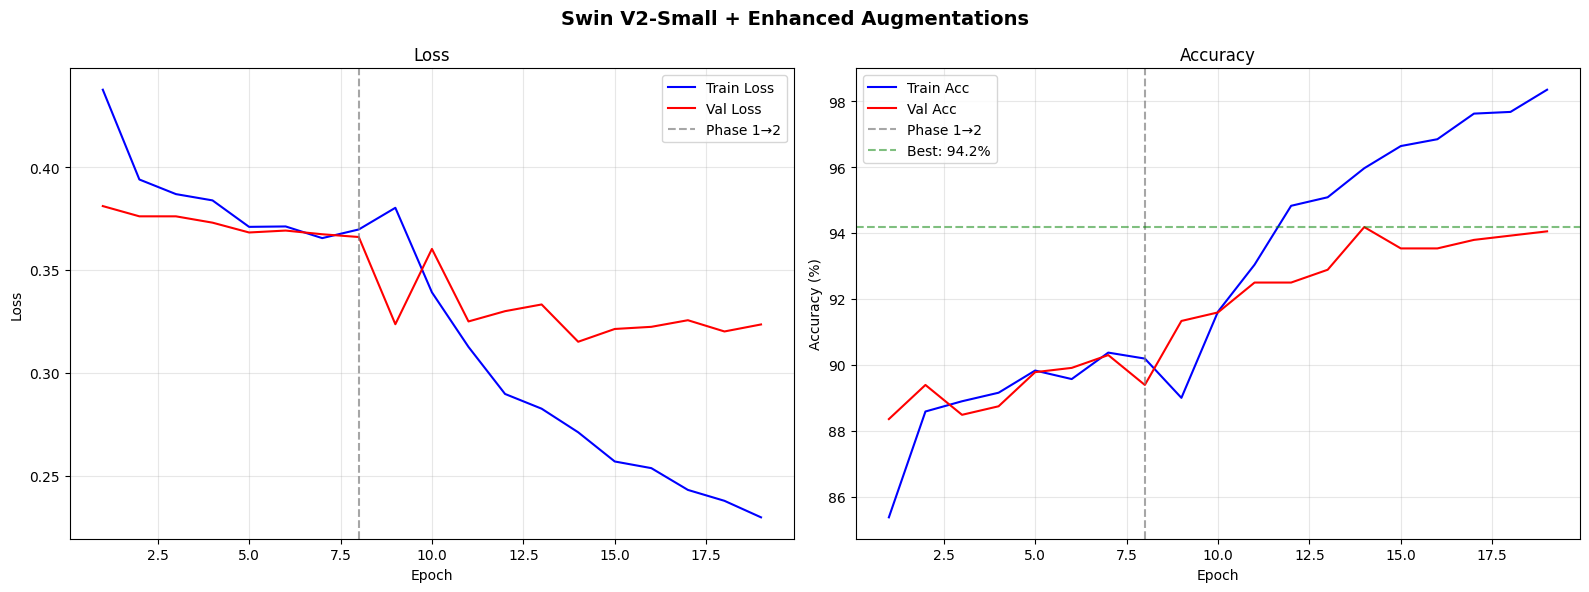

In [ ]:

#  CELL 9: Training curves


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(history["train_loss"]) + 1)
phase_boundary = PHASE1_EPOCHS

axes[0].plot(epochs_range, history["train_loss"], 'b-', label="Train Loss", linewidth=1.5)
axes[0].plot(epochs_range, history["val_loss"], 'r-', label="Val Loss", linewidth=1.5)
axes[0].axvline(x=phase_boundary, color='gray', linestyle='--', alpha=0.7, label="Phase 1→2")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], 'b-', label="Train Acc", linewidth=1.5)
axes[1].plot(epochs_range, history["val_acc"], 'r-', label="Val Acc", linewidth=1.5)
axes[1].axvline(x=phase_boundary, color='gray', linestyle='--', alpha=0.7, label="Phase 1→2")
axes[1].axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f"Best: {best_val_acc:.1f}%")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Swin V2-Small + Enhanced Augmentations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Test**

✅ Loaded best model (epoch 6, val_acc: 94.2%)

  TEST ACCURACY: 95.0%
  TEST LOSS:     0.2906

               precision    recall  f1-score   support

   camouflage       0.95      0.95      0.95       258
no_camouflage       0.95      0.95      0.95       259

     accuracy                           0.95       517
    macro avg       0.95      0.95      0.95       517
 weighted avg       0.95      0.95      0.95       517



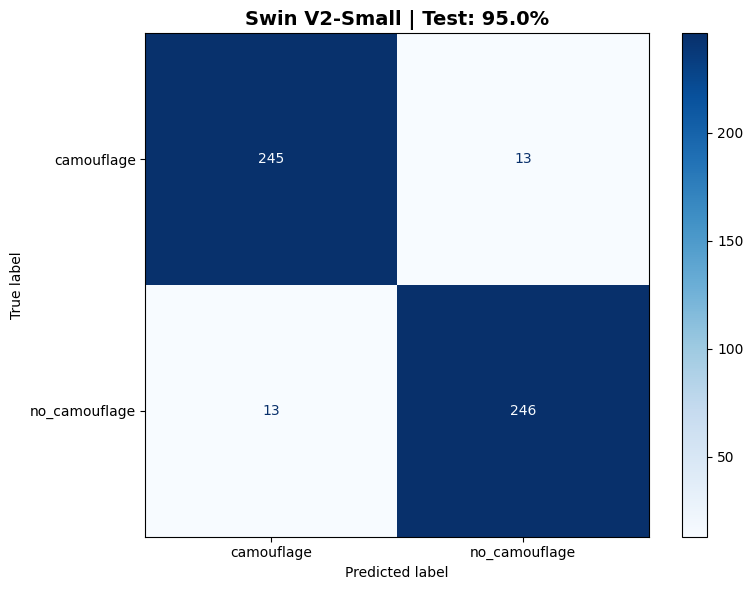

  camouflage: 245/258 = 95.0%
  no_camouflage: 246/259 = 95.0%


In [ ]:

#  CELL 10: Test evaluation


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"✅ Loaded best model (epoch {checkpoint['epoch']}, val_acc: {checkpoint['val_acc']:.1f}%)\n")

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

print(f"{'='*50}")
print(f"  TEST ACCURACY: {test_acc:.1f}%")
print(f"  TEST LOSS:     {test_loss:.4f}")
print(f"{'='*50}\n")

class_names = ["camouflage", "no_camouflage"]
print(classification_report(test_labels, test_preds, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"Swin V2-Small | Test: {test_acc:.1f}%", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for i, cls in enumerate(class_names):
    print(f"  {cls}: {cm[i,i]}/{cm[i].sum()} = {cm[i,i]/cm[i].sum()*100:.1f}%")

**Test on single image**

In [ ]:

#Quick Classification


# ──────────────────────────────────────────────
#   CHANGE IMAGE PATH
# ──────────────────────────────────────────────
IMAGE_PATH = "/content/Screenshot 2026-02-27 181114.png"   # ← PUT YOUR IMAGE PATH
# ──────────────────────────────────────────────

mask, prob_map, has_object = predict_mask(IMAGE_PATH, zoomnext_b4)
original_img = Image.open(IMAGE_PATH).convert("RGB")

if has_object:
    bbox = get_bounding_box(mask)
    if bbox:
        x1, y1, x2, y2 = bbox
        swin_input = original_img.crop((x1, y1, x2, y2)).resize((INPUT_SIZE, INPUT_SIZE), Image.LANCZOS)
        input_type = "CROPPED"
    else:
        swin_input = original_img.resize((INPUT_SIZE, INPUT_SIZE), Image.LANCZOS)
        input_type = "FULL"
else:
    swin_input = original_img.resize((INPUT_SIZE, INPUT_SIZE), Image.LANCZOS)
    input_type = "FULL (no detection)"

img_tensor = val_transform(swin_input).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(img_tensor)
    probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()

pred_idx = int(probs.argmax())
class_names = ["camouflage", "no_camouflage"]
pred_class = class_names[pred_idx]
confidence = probs[pred_idx] * 100
coverage = mask.sum() / mask.size * 100

print(f"{'='*40}")
print(f"  🎯 {pred_class.upper()}")
print(f"  Confidence:  {confidence:.1f}%")
print(f"  Detection:   {'✅ Found' if has_object else '❌ Nothing'}")
print(f"  Input type:  {input_type}")
print(f"  Coverage:    {coverage:.1f}%")
print(f"  Cam prob:    {probs[0]*100:.1f}%")
print(f"  NoCam prob:  {probs[1]*100:.1f}%")
print(f"{'='*40}")

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


  🎯 CAMOUFLAGE
  Confidence:  95.3%
  Detection:   ✅ Found
  Input type:  CROPPED
  Coverage:    8.9%
  Cam prob:    95.3%
  NoCam prob:  4.7%


✅ Model loaded (val_acc: 94.2%)



/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
/tmp/ipykernel_1048/3951632267.py:181: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1048/3951632267.py:181: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


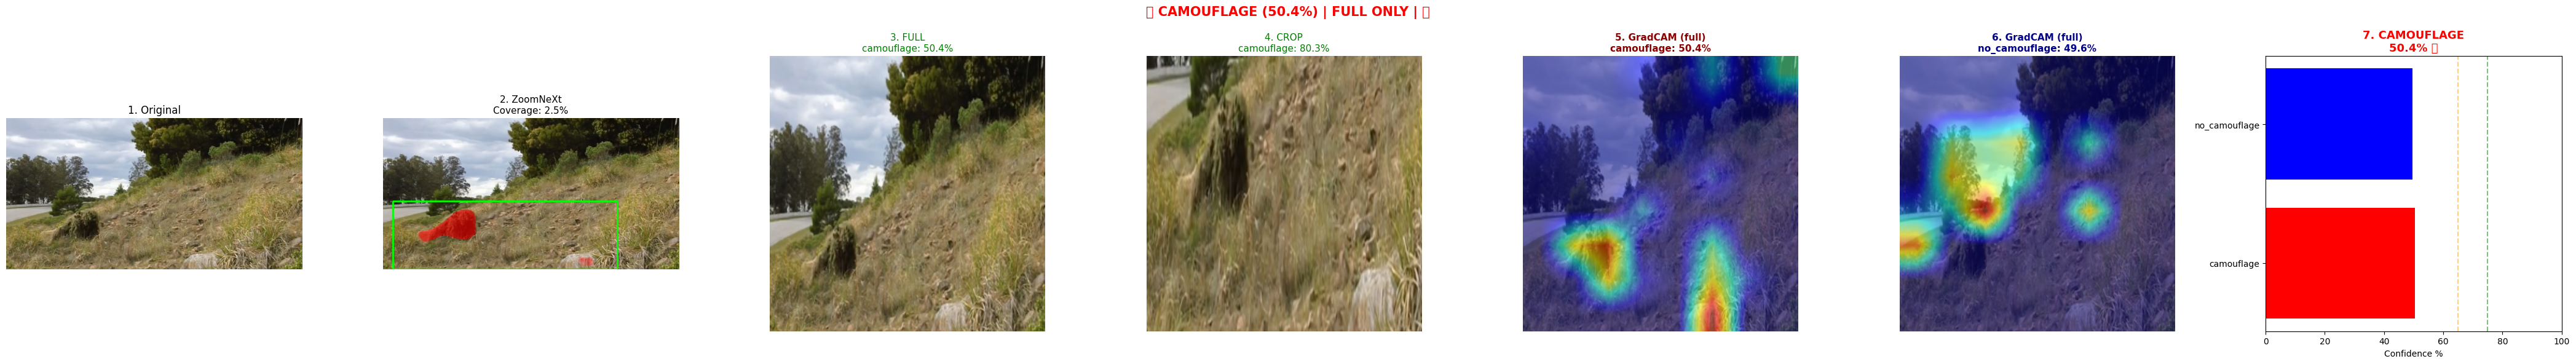


  🎯 PREDICTION:  CAMOUFLAGE
  ────────────────────────────────────────────────────────────
  Confidence:     50.4%
  Cam prob:       50.4%
  NoCam prob:     49.6%
  ────────────────────────────────────────────────────────────
  Coverage:       2.5%
  Fusion:         FULL ONLY
  FULL pred:      camouflage (50.4%)
  CROP pred:      camouflage (80.3%)
  ────────────────────────────────────────────────────────────
  ❌ UNCERTAIN — human review needed

  🔍 RECOMMENDATION:
     This image needs HUMAN REVIEW.
     The model is not confident enough to make a reliable call.
     Possible reasons:
       → Soldier is barely visible or very far away
       → Image quality is low
       → Unusual environment not in training data
       → Ambiguous case (partially camouflaged)


In [ ]:
# ══════════════════════════════════════════════════════════
#  CELL 11: FULL INFERENCE PIPELINE
#  ZoomNeXt → Dual Prediction → GradCAM → Confidence Check
# ══════════════════════════════════════════════════════════

!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ──────────────────────────────────────────────
#  👇 SET THESE ONCE
# ──────────────────────────────────────────────
IMAGE_PATH = "/content/Screenshot 2025-12-28 174547.png"
MODEL_PATH = "/content/drive/MyDrive/swin_checkpoints/swin_v2_small_body.pth"
# ─────────────────────────────────────────────

# Confidence thresholds
HIGH_CONF = 75.0    # >= 75% → trusted
LOW_CONF  = 65.0    # 65-75% → low confidence | < 65% → human review

# Load model
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"✅ Model loaded (val_acc: {checkpoint['val_acc']:.1f}%)\n")


# ── GradCAM helpers ──

def swin_reshape_transform(tensor, height=8, width=8):
    B, HW, C = tensor.size()
    h = w = int(HW ** 0.5)
    result = tensor.reshape(B, h, w, C).permute(0, 3, 1, 2)
    return F.interpolate(result, size=(height, width), mode='bilinear', align_corners=False)

def get_swin_target_layer(model):
    return [model.layers[-1].blocks[-1].norm2]

def classify_single(img_pil, model):
    resized = img_pil.resize((INPUT_SIZE, INPUT_SIZE), Image.LANCZOS)
    tensor = val_transform(resized).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    return probs, resized, tensor


# ═══════════════════════════════════════
#  STAGE 1: ZoomNeXt Detection
# ═══════════════════════════════════════
mask, prob_map, has_object = predict_mask(IMAGE_PATH, zoomnext_b4)
original_img = Image.open(IMAGE_PATH).convert("RGB")
img_array = np.array(original_img)
coverage = mask.sum() / mask.size * 100

# ═══════════════════════════════════════
#  STAGE 2: Dual Prediction
# ═══════════════════════════════════════
class_names = ["camouflage", "no_camouflage"]
full_probs, full_resized, full_tensor = classify_single(original_img, model)

bbox = None
has_crop = False
crop_probs = None
if has_object:
    bbox = get_bounding_box(mask)
    if bbox:
        cropped_img = original_img.crop(bbox)
        crop_probs, crop_resized, crop_tensor = classify_single(cropped_img, model)
        has_crop = True

# ═══════════════════════════════════════
#  STAGE 3: Smart Fusion
# ═══════════════════════════════════════
if has_crop and coverage >= 5.0:
    crop_weight = min(coverage / 50.0, 0.7)
    full_weight = 1.0 - crop_weight
    fused_probs = full_probs * full_weight + crop_probs * crop_weight
    fused_probs = fused_probs / fused_probs.sum()
    fusion_type = f"FUSED (full:{full_weight:.0%} + crop:{crop_weight:.0%})"
else:
    fused_probs = full_probs
    fusion_type = "FULL ONLY"

pred_idx = int(fused_probs.argmax())
other_idx = 1 - pred_idx
pred_class = class_names[pred_idx]
confidence = fused_probs[pred_idx] * 100

# ═══════════════════════════════════════
#  STAGE 4: Confidence Verdict
# ═══════════════════════════════════════
if confidence >= HIGH_CONF:
    verdict = "✅ HIGH CONFIDENCE — prediction trusted"
    verdict_color, verdict_symbol = "green", "✅"
elif confidence >= LOW_CONF:
    verdict = "⚠️ LOW CONFIDENCE — prediction may be unreliable"
    verdict_color, verdict_symbol = "orange", "⚠️"
else:
    verdict = " UNCERTAIN — human review needed"
    verdict_color, verdict_symbol = "red", "❌"

# ═══════════════════════════════════════
#  STAGE 5: GradCAM Visualization
# ═══════════════════════════════════════
if has_crop and coverage >= 5.0 and crop_weight >= 0.5:
    gc_rgb = np.array(crop_resized).astype(np.float32) / 255.0
    gc_tensor, gc_label = crop_tensor, "GradCAM (crop)"
else:
    gc_rgb = np.array(full_resized).astype(np.float32) / 255.0
    gc_tensor, gc_label = full_tensor, "GradCAM (full)"

target_layer = get_swin_target_layer(model)

cam_p = GradCAM(model=model, target_layers=target_layer, reshape_transform=swin_reshape_transform)
ov_pred = show_cam_on_image(gc_rgb, cam_p(input_tensor=gc_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0, :], use_rgb=True)
cam_p.__del__()

cam_o = GradCAM(model=model, target_layers=target_layer, reshape_transform=swin_reshape_transform)
ov_other = show_cam_on_image(gc_rgb, cam_o(input_tensor=gc_tensor, targets=[ClassifierOutputTarget(other_idx)])[0, :], use_rgb=True)
cam_o.__del__()

# ═══════════════════════════════════════
#  VISUALIZATION — 7 panels
# ═══════════════════════════════════════
fig, axes = plt.subplots(1, 7, figsize=(42, 6))

axes[0].imshow(original_img)
axes[0].set_title("1. Original", fontsize=12)
axes[0].axis("off")

overlay = img_array.copy()
if has_object:
    red = np.zeros_like(img_array); red[:, :, 0] = 255
    alpha_map = np.stack([prob_map] * 3, axis=-1) * 0.6
    overlay = (img_array * (1 - alpha_map) + red * alpha_map).astype(np.uint8)
    if bbox:
        cv2.rectangle(overlay, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 3)
axes[1].imshow(overlay)
axes[1].set_title(f"2. ZoomNeXt\nCoverage: {coverage:.1f}%", fontsize=11)
axes[1].axis("off")

axes[2].imshow(full_resized)
fp, fc = class_names[int(full_probs.argmax())], full_probs.max() * 100
axes[2].set_title(f"3. FULL\n{fp}: {fc:.1f}%", fontsize=11,
                  color='green' if fp == pred_class else 'orange')
axes[2].axis("off")

if has_crop and crop_probs is not None:
    axes[3].imshow(crop_resized)
    cp, cc = class_names[int(crop_probs.argmax())], crop_probs.max() * 100
    axes[3].set_title(f"4. CROP\n{cp}: {cc:.1f}%", fontsize=11,
                      color='green' if cp == pred_class else 'orange')
else:
    axes[3].text(0.5, 0.5, "No crop\n(no detection)", ha='center', va='center', fontsize=12, color='gray')
    axes[3].set_title("4. CROP", fontsize=11)
axes[3].axis("off")

axes[4].imshow(ov_pred)
axes[4].set_title(f"5. {gc_label}\n{class_names[pred_idx]}: {confidence:.1f}%",
                  fontsize=11, fontweight='bold', color='darkred')
axes[4].axis("off")

axes[5].imshow(ov_other)
axes[5].set_title(f"6. {gc_label}\n{class_names[other_idx]}: {fused_probs[other_idx]*100:.1f}%",
                  fontsize=11, fontweight='bold', color='darkblue')
axes[5].axis("off")

bar_colors = ['red', 'blue']
axes[6].barh(class_names, fused_probs * 100, color=bar_colors)
axes[6].axvline(x=HIGH_CONF, color='green', linestyle='--', alpha=0.5)
axes[6].axvline(x=LOW_CONF, color='orange', linestyle='--', alpha=0.5)
axes[6].set_xlim(0, 100)
axes[6].set_title(f"7. {pred_class.upper()}\n{confidence:.1f}% {verdict_symbol}",
                  fontsize=13, fontweight='bold', color=verdict_color)
axes[6].set_xlabel("Confidence %")

plt.suptitle(f"🎯 {pred_class.upper()} ({confidence:.1f}%) | {fusion_type} | {verdict_symbol}",
             fontsize=15, fontweight='bold', color=verdict_color)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════
#  FINAL REPORT
# ═══════════════════════════════════════
print(f"\n  {'='*60}")
print(f"   PREDICTION:  {pred_class.upper()}")
print(f"  {'─'*60}")
print(f"  Confidence:     {confidence:.1f}%")
print(f"  Cam prob:       {fused_probs[0]*100:.1f}%")
print(f"  NoCam prob:     {fused_probs[1]*100:.1f}%")
print(f"  {'─'*60}")
print(f"  Coverage:       {coverage:.1f}%")
print(f"  Fusion:         {fusion_type}")
print(f"  FULL pred:      {class_names[int(full_probs.argmax())]} ({full_probs.max()*100:.1f}%)")
if has_crop and crop_probs is not None:
    print(f"  CROP pred:      {class_names[int(crop_probs.argmax())]} ({crop_probs.max()*100:.1f}%)")
print(f"  {'─'*60}")
print(f"  {verdict}")
print(f"  {'='*60}")

if confidence < LOW_CONF:
    print(f"\n   RECOMMENDATION:")
    print(f"     This image needs HUMAN REVIEW.")
    print(f"     The model is not confident enough to make a reliable call.")
    print(f"     Possible reasons:")
    print(f"       → Soldier is barely visible or very far away")
    print(f"       → Image quality is low")
    print(f"       → Unusual environment not in training data")
    print(f"       → Ambiguous case (partially camouflaged)")
elif confidence < HIGH_CONF:
    print(f"\n  ⚠️ NOTE:")
    print(f"     Prediction is likely correct but confidence is moderate.")
    print(f"     Consider verifying if this is a critical decision.")



